In [1]:
# To avoid warning messages
import warnings
warnings.filterwarnings('ignore')

# Import libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import datetime
import pandas as pd
import os

# Key imports: Replace linregress with theilslopes for robust trend analysis
from scipy.stats import theilslopes, pearsonr
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load sea ice data
ds_si = xr.open_dataset("/A04/so_data/DATA/sea_ice_concenytration_from_1998_2024_NSIDC.nc")

# Open xarray dataset object via an OPeNDAP connection
grid_url = 'https://polarwatch.noaa.gov/erddap/griddap/pstere_gridcell_S25k'
grid_area = xr.open_dataset(grid_url)

# Subset grid area to match SIC data grids
sub_area = grid_area.sel(x=slice(ds_si['xgrid'].min(), ds_si['xgrid'].max()),
                         y=slice(ds_si['ygrid'].max(), ds_si['ygrid'].min()))

# Clean and prepare data
ds_si = ds_si.where(ds_si.cdr_seaice_conc_monthly <= 1)
ds_si['area'] = (('ygrid', 'xgrid'), sub_area.cell_area.values)
ds_si['siext'] = ds_si['area'] * ds_si['cdr_seaice_conc_monthly']

print("Data loaded and processed successfully")
print(ds_si)

Data loaded and processed successfully
<xarray.Dataset> Size: 409MB
Dimensions:                  (time: 324, ygrid: 332, xgrid: 316)
Coordinates:
  * time                     (time) datetime64[ns] 3kB 1998-01-01 ... 2024-12-01
  * ygrid                    (ygrid) float32 1kB 4.338e+06 ... -3.938e+06
  * xgrid                    (xgrid) float32 1kB -3.938e+06 ... 3.938e+06
Data variables:
    cdr_seaice_conc_monthly  (time, ygrid, xgrid) float32 136MB 0.0 0.0 ... 0.0
    area                     (ygrid, xgrid) float64 839kB 4.441e+08 ... 4.601...
    siext                    (ygrid, xgrid, time) float64 272MB 0.0 0.0 ... 0.0


In [3]:
# Compute SIC anomaly by removing the monthly climatological mean (removes seasonal cycle)
monthly_clim_sic = ds_si['cdr_seaice_conc_monthly'].groupby('time.month').mean()
ds_si['sic_anomaly'] = ds_si['cdr_seaice_conc_monthly'].groupby('time.month') - monthly_clim_sic

# Compute sea ice area anomaly: area × SIC anomaly (in km²)
ds_si['siext_anomaly'] = ds_si['area'] * ds_si['sic_anomaly']

print("SIC anomaly computed and added to ds_si")
print(ds_si)

SIC anomaly computed and added to ds_si
<xarray.Dataset> Size: 817MB
Dimensions:                  (time: 324, ygrid: 332, xgrid: 316)
Coordinates:
  * time                     (time) datetime64[ns] 3kB 1998-01-01 ... 2024-12-01
  * ygrid                    (ygrid) float32 1kB 4.338e+06 ... -3.938e+06
  * xgrid                    (xgrid) float32 1kB -3.938e+06 ... 3.938e+06
    month                    (time) int64 3kB 1 2 3 4 5 6 7 ... 6 7 8 9 10 11 12
Data variables:
    cdr_seaice_conc_monthly  (time, ygrid, xgrid) float32 136MB 0.0 0.0 ... 0.0
    area                     (ygrid, xgrid) float64 839kB 4.441e+08 ... 4.601...
    siext                    (ygrid, xgrid, time) float64 272MB 0.0 0.0 ... 0.0
    sic_anomaly              (time, ygrid, xgrid) float32 136MB 0.0 0.0 ... 0.0
    siext_anomaly            (ygrid, xgrid, time) float64 272MB 0.0 0.0 ... 0.0


In [4]:
# === YEARLY ANALYSIS USING SEN'S SLOPE (Theil-Sen Estimator) ===

# Resampling to yearly means
ds_siext_1Y = ds_si['siext'].resample(time='1Y').mean()

vals1 = (10**-6)*ds_siext_1Y.sum(dim=["xgrid", "ygrid"], skipna=True).data
dates1 = ds_siext_1Y.time.astype('datetime64')

# Computing trends using Sen's slope (Theil-Sen estimator)
x_vals = np.arange(len(vals1))
slope, intercept, lower_slope, upper_slope = theilslopes(vals1, x_vals, alpha=0.05)

# Calculate regression line using Sen's slope
regression_line = intercept + slope * x_vals

# Calculate Pearson correlation for comparison
r, p = pearsonr(x_vals, vals1)

# Print results
print("=== SEN'S SLOPE ANALYSIS (Yearly Sea Ice Extent) ===")
print(f"Sen's Slope: {slope:.6f} (10^6 km²/year)")
print(f"Intercept: {intercept:.6f}")
print(f"95% Confidence interval: [{lower_slope:.6f}, {upper_slope:.6f}]")
print(f"Correlation coefficient: {r:.6f}")
print(f"P-value: {p:.6g}")
print(f"\nSen's slope in original units: {slope*1e6:.1f} km²/year")

=== SEN'S SLOPE ANALYSIS (Yearly Sea Ice Extent) ===
Sen's Slope: -35868.779836 (10^6 km²/year)
Intercept: 10415231.376329
95% Confidence interval: [-61594.216954, 3549.156633]
Correlation coefficient: -0.507201
P-value: 0.00692816

Sen's slope in original units: -35868779835.9 km²/year


In [5]:
# === MONTHLY ANALYSIS USING SEN'S SLOPE ===

# Computing the February and September datasets
ds_si_02 = ds_si.sel(time=ds_si['time.month'] == 2)
ds_si_09 = ds_si.sel(time=ds_si['time.month'] == 9)

# February analysis with Sen's slope (using anomalies for preliminary analysis)
vals_feb = (10**-6)*ds_si_02['siext'].sum(dim=["xgrid", "ygrid"], skipna=True).data
dates_feb = ds_si_02.time.astype('datetime64')
x_feb = np.arange(len(vals_feb))

slope_feb, intercept_feb, lower_feb, upper_feb = theilslopes(vals_feb, x_feb, alpha=0.95)
regression_feb = intercept_feb + slope_feb * x_feb
r_feb, p_feb = pearsonr(x_feb, vals_feb)

print("=== FEBRUARY SEN'S SLOPE ANALYSIS ===")
print(f"Sen's Slope: {slope_feb:.6f} (10^6 km²/year)")
print(f"95% CI: [{lower_feb:.6f}, {upper_feb:.6f}]")
print(f"Correlation: {r_feb:.6f}, P-value: {p_feb:.6g}")
print(f"Sen's slope in original units: {slope_feb*1e6:.1f} km²/year")

# September analysis with Sen's slope
vals_sep = (10**-6)*ds_si_09['siext'].sum(dim=["xgrid", "ygrid"], skipna=True).data
dates_sep = ds_si_09.time.astype('datetime64')
x_sep = np.arange(len(vals_sep))

slope_sep, intercept_sep, lower_sep, upper_sep = theilslopes(vals_sep, x_sep, alpha=0.95)
regression_sep = intercept_sep + slope_sep * x_sep
r_sep, p_sep = pearsonr(x_sep, vals_sep)

print("\n=== SEPTEMBER SEN'S SLOPE ANALYSIS ===")
print(f"Sen's Slope: {slope_sep:.6f} (10^6 km²/year)")
print(f"95% CI: [{lower_sep:.6f}, {upper_sep:.6f}]")
print(f"Correlation: {r_sep:.6f}, P-value: {p_sep:.6g}")
print(f"Sen's slope in original units: {slope_sep*1e6:.1f} km²/year")

=== FEBRUARY SEN'S SLOPE ANALYSIS ===
Sen's Slope: -19087.885575 (10^6 km²/year)
95% CI: [-42063.686195, -2159.642096]
Correlation: -0.445819, P-value: 0.01977
Sen's slope in original units: -19087885574.8 km²/year

=== SEPTEMBER SEN'S SLOPE ANALYSIS ===
Sen's Slope: -28858.265428 (10^6 km²/year)
95% CI: [-60152.934755, 3807.959393]
Correlation: -0.435982, P-value: 0.0230065
Sen's slope in original units: -28858265428.5 km²/year


In [6]:
# === MANUAL GRID-BY-GRID SEN'S SLOPE ANALYSIS ===
# Robust spatial trend analysis using Sen's slope at each grid point

print("Computing Sen's slope trends manually for February (Summer) data...")

# Initialize arrays for Sen's slope results
trend_array_feb = np.full((ds_si_02.sizes['ygrid'], ds_si_02.sizes['xgrid']), np.nan)
pval_array_feb = np.full((ds_si_02.sizes['ygrid'], ds_si_02.sizes['xgrid']), np.nan)

# Loop over each grid point for February data
for i in range(ds_si_02.sizes['ygrid']):
    for j in range(ds_si_02.sizes['xgrid']):
        # Extract the SIC anomaly time series for the current point (i, j)
        y = ds_si_02['sic_anomaly'].data[:, i, j]  # Shape: (time,)
        
        if not np.isnan(y).all() and np.isfinite(y).sum() > 5:  # At least 5 valid points
            try:
                # Perform Sen's slope regression for the time series at this point
                x_grid = np.arange(ds_si_02.sizes['time'])
                slope_grid, intercept_grid, lower_grid, upper_grid = theilslopes(y, x_grid, alpha=0.05)
                
                # Store the slope (trend) in the trend array
                trend_array_feb[i, j] = slope_grid
                
                # Calculate p-value using Pearson correlation (approximation)
                r_grid, p_grid = pearsonr(x_grid, y)
                pval_array_feb[i, j] = p_grid
                
            except Exception as e:
                # Handle any errors in calculation
                trend_array_feb[i, j] = np.nan
                pval_array_feb[i, j] = np.nan

print("Computing Sen's slope trends manually for September (Winter) data...")

# Initialize arrays for September
trend_array_sep = np.full((ds_si_09.sizes['ygrid'], ds_si_09.sizes['xgrid']), np.nan)
pval_array_sep = np.full((ds_si_09.sizes['ygrid'], ds_si_09.sizes['xgrid']), np.nan)

# Loop over each grid point for September data
for i in range(ds_si_09.sizes['ygrid']):
    for j in range(ds_si_09.sizes['xgrid']):
        # Extract the SIC anomaly time series for the current point (i, j)
        y = ds_si_09['sic_anomaly'].data[:, i, j]  # Shape: (time,)
        
        if not np.isnan(y).all() and np.isfinite(y).sum() > 5:  # At least 5 valid points
            try:
                # Perform Sen's slope regression for the time series at this point
                x_grid = np.arange(ds_si_09.sizes['time'])
                slope_grid, intercept_grid, lower_grid, upper_grid = theilslopes(y, x_grid, alpha=0.05)
                
                # Store the slope (trend) in the trend array
                trend_array_sep[i, j] = slope_grid
                
                # Calculate p-value using Pearson correlation (approximation)
                r_grid, p_grid = pearsonr(x_grid, y)
                pval_array_sep[i, j] = p_grid
                
            except Exception as e:
                # Handle any errors in calculation
                trend_array_sep[i, j] = np.nan
                pval_array_sep[i, j] = np.nan

# Create DataArrays for the manual results
manual_trend_feb = xr.DataArray(trend_array_feb, dims=['ygrid', 'xgrid'], 
                               coords={'ygrid': ds_si_02['ygrid'], 'xgrid': ds_si_02['xgrid']})
manual_pval_feb = xr.DataArray(pval_array_feb, dims=['ygrid', 'xgrid'], 
                              coords={'ygrid': ds_si_02['ygrid'], 'xgrid': ds_si_02['xgrid']})

manual_trend_sep = xr.DataArray(trend_array_sep, dims=['ygrid', 'xgrid'], 
                               coords={'ygrid': ds_si_09['ygrid'], 'xgrid': ds_si_09['xgrid']})
manual_pval_sep = xr.DataArray(pval_array_sep, dims=['ygrid', 'xgrid'], 
                              coords={'ygrid': ds_si_09['ygrid'], 'xgrid': ds_si_09['xgrid']})

print("Manual Sen's slope computation completed!")
print(f"February valid trends: {np.isfinite(trend_array_feb).sum()} grid points")
print(f"September valid trends: {np.isfinite(trend_array_sep).sum()} grid points")

Computing Sen's slope trends manually for February (Summer) data...
Computing Sen's slope trends manually for September (Winter) data...
Manual Sen's slope computation completed!
February valid trends: 82907 grid points
September valid trends: 82907 grid points


In [7]:
# Load Antarctic mapping function and define antarctic_map
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.path as mpath

# Load oceanographic fronts data
saccf = pd.read_csv('/A04/so_data/front//saccf.txt', header=None, sep='\s+', na_values='%', names=['lon','lat'])
sbdy = pd.read_csv('/A04/so_data/front//SB.txt', header=None, sep='\s+', na_values='%', names=['lon','lat'])
io= pd.read_csv( '/A04/so_data/shapefile/coordinates.txt', header=None, sep='\s+', na_values='%', names=['lon','lat'])
ao= pd.read_csv( '/A04/so_data/shapefile/coordinates_AO.txt', header=None, sep='\s+', na_values='%', names=['lon','lat'])
po= pd.read_csv( '/A04/so_data/shapefile/coordinates_PO.txt', header=None, sep='\s+', na_values='%', names=['lon','lat'])
# Define the antarctic_map function
def antarctic_map(ax):
    nonproj = ccrs.PlateCarree()
    
    # Set the extent and add features
    ax.set_extent([-180, 180, -90, -53], nonproj)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.25)
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN, color='black')
    
    # Add gridlines with labels and custom style
    ax.gridlines(nonproj, draw_labels=False, linewidth=1, xlocs=range(-180, 171, 20), ylocs=[],
                 color='gray', alpha=0.5, linestyle='--', zorder=10)
    ax.gridlines(nonproj, draw_labels=False, linewidth=1, xlocs=[], ylocs=range(-90, -53, 10),
                 color='gray', alpha=0.5, linestyle='--', zorder=10)
    
    # Set the boundary to a circle
    theta = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
    
    # Add oceanographic fronts
    labels = ['SACCF', 'SB']
    lines = [saccf, sbdy]
    colors = ['red', 'black']

    for label, line, color in zip(labels, lines, colors):
        ax.plot(line['lon'], line['lat'], label=label, lw=0.5, ls='-', 
                color=color, transform=ccrs.PlateCarree(), zorder=1)
    ax.plot(io['lon'], io['lat'], color='Black', transform=ccrs.PlateCarree(), linewidth=2)
    ax.plot(ao['lon'], ao['lat'], color='Black', transform=ccrs.PlateCarree(), linewidth=2)
    ax.plot(po['lon'], po['lat'], color='Black', transform=ccrs.PlateCarree(), linewidth=2, zorder=2)
    
    return ax

print("Antarctic mapping function loaded successfully")

Antarctic mapping function loaded successfully


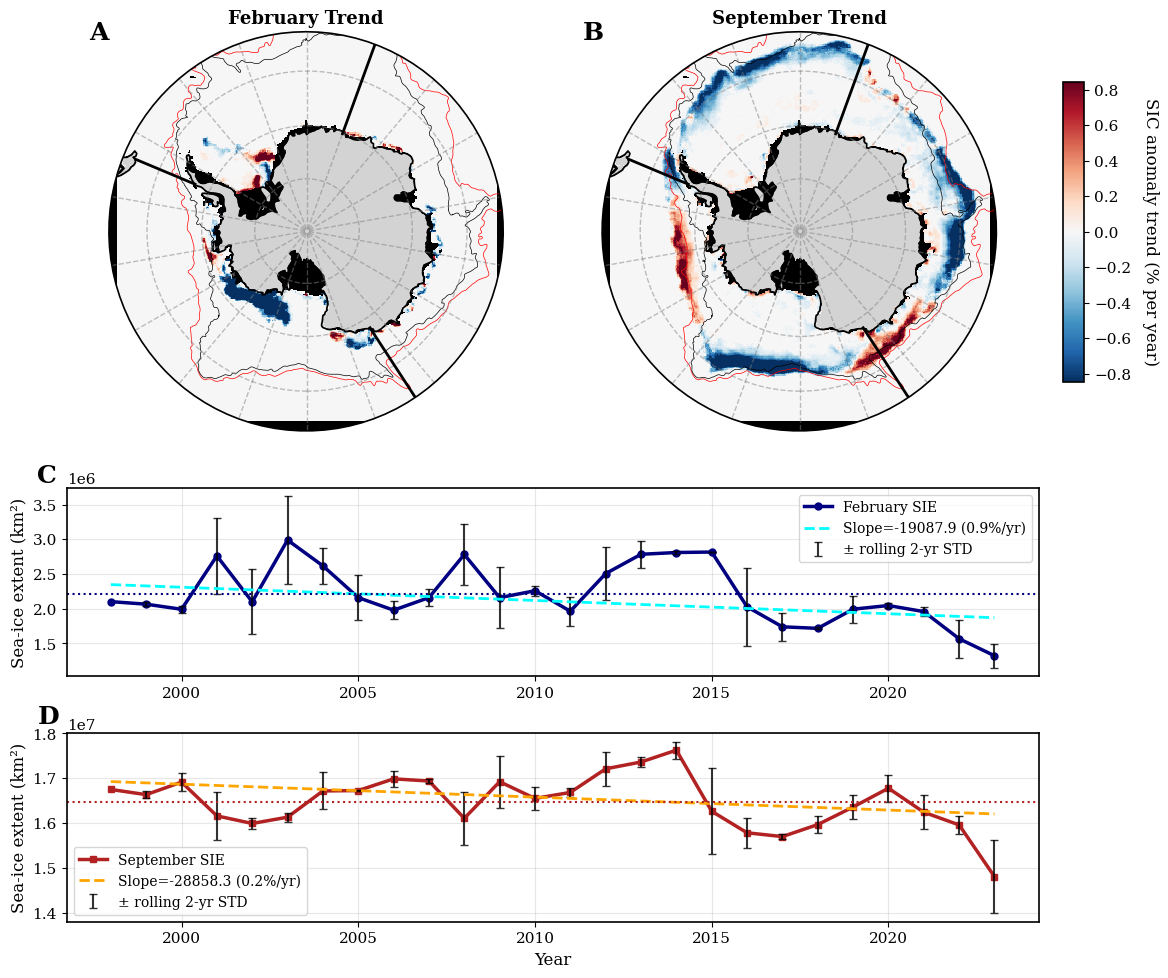


TIME SERIES SUMMARY
February STD = 428831.281
September STD = 598875.745


In [24]:
# ============================================================
# COMPREHENSIVE PUBLICATION FIGURE
# Row 1 : Spatial Sen's slope maps
# Row 2 : February time series
# Row 3 : September time series
# ============================================================

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec


# ============================================================
# PUBLICATION STYLE
# ============================================================

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.2,
    "savefig.dpi": 600,
})


# ============================================================
# PREPARE TIME SERIES
# ============================================================

ROLL_WIN = 2


# ---------- February ----------
df_feb = pd.DataFrame({
    "time": dates_feb[:-1],
    "sie": vals_feb_actual[:-1]
})

df_feb["year"] = pd.to_datetime(df_feb["time"]).dt.year

feb_yearly = df_feb.groupby("year")["sie"].mean()

feb_years = feb_yearly.index.values
feb_y = feb_yearly.values

feb_y_std_roll = (
    pd.Series(feb_y)
    .rolling(
        ROLL_WIN,
        center=True,
        min_periods=2
    )
    .std()
    .to_numpy()
)

x_feb = np.arange(len(feb_years))

feb_trend = (
    intercept_feb_actual
    + slope_feb_actual * x_feb
)

feb_y_std_overall = np.nanstd(
    feb_y,
    ddof=1
)


# ---------- September ----------
df_sep = pd.DataFrame({
    "time": dates_sep[:-1],
    "sie": vals_sep_actual[:-1]
})

df_sep["year"] = (
    pd.to_datetime(
        df_sep["time"]
    ).dt.year
)

sep_yearly = (
    df_sep.groupby("year")["sie"]
    .mean()
)

sep_years = sep_yearly.index.values
sep_y = sep_yearly.values

sep_y_std_roll = (
    pd.Series(sep_y)
    .rolling(
        ROLL_WIN,
        center=True,
        min_periods=2
    )
    .std()
    .to_numpy()
)

x_sep = np.arange(len(sep_years))

sep_trend = (
    intercept_sep_actual
    + slope_sep_actual * x_sep
)

sep_y_std_overall = np.nanstd(
    sep_y,
    ddof=1
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig = plt.figure(
    figsize=(12, 10)
)

gs = GridSpec(
    3,
    2,
    figure=fig,
    height_ratios=[1.8, 0.85, 0.85],   # larger maps
    width_ratios=[1, 1],
    hspace=0.22,
    wspace=0.03                        # tighter between maps
)


# ============================================================
# ROW 1 — SPATIAL MAPS
# ============================================================

proj = ccrs.Stereographic(
    central_latitude=-90,
    central_longitude=0,
    true_scale_latitude=-70
)

ax1 = fig.add_subplot(
    gs[0, 0],
    projection=proj
)

ax2 = fig.add_subplot(
    gs[0, 1],
    projection=proj
)


trend_feb = manual_trend_feb * 100
trend_sep = manual_trend_sep * 100


vals = np.concatenate([
    trend_feb.values.ravel(),
    trend_sep.values.ravel()
])

vals = vals[
    ~np.isnan(vals)
]


vmax = np.nanpercentile(
    np.abs(vals),
    98
)

norm = TwoSlopeNorm(
    vmin=-vmax,
    vcenter=0,
    vmax=vmax
)


m1 = trend_feb.plot(
    ax=ax1,
    cmap="RdBu_r",
    norm=norm,
    add_colorbar=False
)

m2 = trend_sep.plot(
    ax=ax2,
    cmap="RdBu_r",
    norm=norm,
    add_colorbar=False
)


antarctic_map(ax1)
antarctic_map(ax2)


ax1.set_title(
    "February Trend",
    fontweight="bold"
)

ax2.set_title(
    "September Trend",
    fontweight="bold"
)


ax1.text(
    -0.05,
    .98,
    "A",
    transform=ax1.transAxes,
    fontsize=18,
    fontweight="bold"
)

ax2.text(
    -0.05,
    .98,
    "B",
    transform=ax2.transAxes,
    fontsize=18,
    fontweight="bold"
)


# Shared colorbar
cax = fig.add_axes(
    [0.91, 0.60, 0.018, 0.30]
) # [left, bottom, width, height] in figure coordinates

cb = fig.colorbar(
    m2,
    cax=cax
)

cb.set_label(
    "SIC anomaly trend (% per year)",
    rotation=270,
    labelpad=20
)


# ============================================================
# ROW 2 — FEBRUARY
# ============================================================

ax3 = fig.add_subplot(
    gs[1, :]
)

ax3.plot(
    feb_years,
    feb_y,
    color="navy",
    lw=2.5,
    marker="o",
    ms=5,
    label="February SIE"
)

ax3.errorbar(
    feb_years,
    feb_y,
    yerr=feb_y_std_roll,
    fmt="none",
    ecolor="black",
    capsize=3,
    alpha=0.8, label=f'± rolling {ROLL_WIN}-yr STD'
)

ax3.plot(
    feb_years,
    feb_trend,
    "--",
    color="cyan",
    lw=2,
    label=(
        f"Slope={slope_feb_actual:.1f}"
        f" ({feb_percent_per_year:.1f}%/yr)"
    )
)

ax3.axhline(
    np.nanmean(feb_y),
    color="navy",
    ls=":"
)

# ax3.set_title(
#     "February",
#     fontweight="bold"
# )

ax3.set_ylabel(
    "Sea-ice extent (km²)"
)

ax3.grid(alpha=0.3)

ax3.legend()

ax3.text(
    -0.03,
    1.03,
    "C",
    transform=ax3.transAxes,
    fontsize=18,
    fontweight="bold"
)


# ============================================================
# ROW 3 — SEPTEMBER
# ============================================================

ax4 = fig.add_subplot(
    gs[2, :]
)

ax4.plot(
    sep_years,
    sep_y,
    color="firebrick",
    lw=2.5,
    marker="s",
    ms=5,
    label="September SIE"
)

ax4.errorbar(
    sep_years,
    sep_y,
    yerr=sep_y_std_roll,
    fmt="none",
    ecolor="black",
    capsize=3,
    alpha=0.8, label=f'± rolling {ROLL_WIN}-yr STD'
)

ax4.plot(
    sep_years,
    sep_trend,
    "--",
    color="orange",
    lw=2,
    label=(
        f"Slope={slope_sep_actual:.1f}"
        f" ({sep_percent_per_year:.1f}%/yr)"
    )
)

ax4.axhline(
    np.nanmean(sep_y),
    color="firebrick",
    ls=":"
)

# ax4.set_title(
#     "September",
#     fontweight="bold"
# )

ax4.set_xlabel(
    "Year"
)

ax4.set_ylabel(
    "Sea-ice extent (km²)"
)

ax4.grid(alpha=0.3)

ax4.legend()

ax4.text(
    -0.03,
    1.05,
    "D",
    transform=ax4.transAxes,
    fontsize=18,
    fontweight="bold"
)


# ============================================================
# FINAL
# ============================================================

plt.subplots_adjust(
    left=0.08,
    right=0.89,
    top=0.95,
    bottom=0.06
)

plt.show()


print("\n" + "="*70)
print("TIME SERIES SUMMARY")
print("="*70)

print(
    f"February STD = "
    f"{feb_y_std_overall:.3f}"
)

print(
    f"September STD = "
    f"{sep_y_std_overall:.3f}"
)

print("="*70)